In [1]:
#-----------------------------
# Packages Import
#-----------------------------
#%matplotlib inline


import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import torch

# Used to handle picture drawings
import cv2

# Used Handle directories and paths
import os

# Used to create and compute random angles
import random
import math

# Used to create the image labels
import json

#used to handle torch images
from torchvision.transforms import v2
from torchvision.io import decode_image

In [7]:
#--------------------------
# Constants across the project
#----------------------------

# Crossing type mappings (5 classes: overcrossing, undercrossing, line, empty, full)
CROSSING_TO_IDX = {"overcrossing": 0, "undercrossing": 1, "line": 2, "empty": 3, "full": 4}
IDX_TO_CROSSING = {v: k for k, v in CROSSING_TO_IDX.items()}

# Image window and dot channel parameters
WINDOW_SIZE = (64, 64)



In [8]:
#------------------------
# Basic Drawing functions
#-----------------------

def get_boundary_point(angle, size):
    """Calculates where a line at 'angle' hits the image boundary."""
    h, w = size
    cx, cy = w // 2, h // 2

    dist = max(w, h)

    x1 = int(cx - dist * math.cos(angle))
    y1 = int(cy - dist * math.sin(angle))
    x2 = int(cx + dist * math.cos(angle))
    y2 = int(cy + dist * math.sin(angle))

    _, p1, p2 = cv2.clipLine((0, 0, w, h), (x1, y1), (x2, y2))
    return [p1, p2]


def draw_strand(img, angle, thickness):
    """Draws a line through the center at the given angle (radians)."""
    h, w = img.shape[:2]
    p_in, p_out = get_boundary_point(angle, (h, w))
    cv2.line(img, p_in, p_out, (0, 0, 0), thickness, cv2.LINE_AA)


def draw_over_strand(img, angle, thickness, space_between_strands):
    """Draws a strand with a white gap (for over-crossing effect)."""
    h, w = img.shape[:2]
    p_in, p_out = get_boundary_point(angle, (h, w))
    cv2.line(img, p_in, p_out, (255, 255, 255), thickness + space_between_strands, cv2.LINE_AA)
    cv2.line(img, p_in, p_out, (0, 0, 0), thickness, cv2.LINE_AA)

    

In [9]:
#------------------
# Advanced drawing functions + channel helpers
#------------------

SPACE_BETWEEN_STRANDS = 8


def draw_straight_line(img, angle, thickness):
    """Draws a single straight line at the given angle (radians)."""
    draw_strand(img, angle, thickness * 2)


def draw_over_crossing(img, main_angle, other_angle, thickness):
    """Draws main strand on top of other strand (over-crossing)."""
    draw_strand(img, other_angle, thickness * 2)
    draw_over_strand(img, main_angle, thickness * 2, SPACE_BETWEEN_STRANDS)


def draw_under_crossing(img, main_angle, other_angle, thickness):
    """Draws main strand under other strand (under-crossing)."""
    draw_strand(img, main_angle, thickness * 2)
    draw_over_strand(img, other_angle, thickness * 2, SPACE_BETWEEN_STRANDS)

    
DOT_RADIUS_FROM_CENTER = 22   # pixels from center for direction dot
DOT_DRAW_RADIUS = 3           # radius of the drawn dot circle

def make_dot_channel(angle, window_size=WINDOW_SIZE):
    """
    Creates a dot image with a small filled circle at
    (cx + r*cos(angle), cy + r*sin(angle)) from center.
    This will be a channel for the NN
    Returns: float32 [H, W] with values in [0, 1]
    """
    dot_img = np.zeros(window_size, dtype=np.float32)
    cx, cy = window_size[1] // 2, window_size[0] // 2
    dot_x = int(round(cx + DOT_RADIUS_FROM_CENTER * math.cos(angle)))
    dot_y = int(round(cy + DOT_RADIUS_FROM_CENTER * math.sin(angle)))
    dot_x = max(DOT_DRAW_RADIUS, min(window_size[1] - DOT_DRAW_RADIUS - 1, dot_x))
    dot_y = max(DOT_DRAW_RADIUS, min(window_size[0] - DOT_DRAW_RADIUS - 1, dot_y))
    cv2.circle(dot_img, (dot_x, dot_y), DOT_DRAW_RADIUS, 1.0, -1)
    return dot_img  # [H, W] float32


SOBEL_THRESHOLD = 0.05  # suppress gradients weaker than this magnitude

def compute_sobel_channels(gray_np):
    """
    Computes Sobel X and Y gradient channels from a grayscale numpy array.
    gray_np: float32 [H, W] with values in [0, 1]
    Returns: (sobel_x, sobel_y), each float32 [H, W] approximately in [-1, 1]

    Small gradients (magnitude < SOBEL_THRESHOLD) are zeroed out so that
    only strong edges (strand boundaries) contribute signal.
    """
    gray_u8 = (gray_np * 255).astype(np.uint8)
    sobel_x = cv2.Sobel(gray_u8, cv2.CV_32F, 1, 0, ksize=3) / 1020.0
    sobel_y = cv2.Sobel(gray_u8, cv2.CV_32F, 0, 1, ksize=3) / 1020.0

    magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    mask = magnitude > SOBEL_THRESHOLD
    sobel_x *= mask
    sobel_y *= mask

    return sobel_x, sobel_y



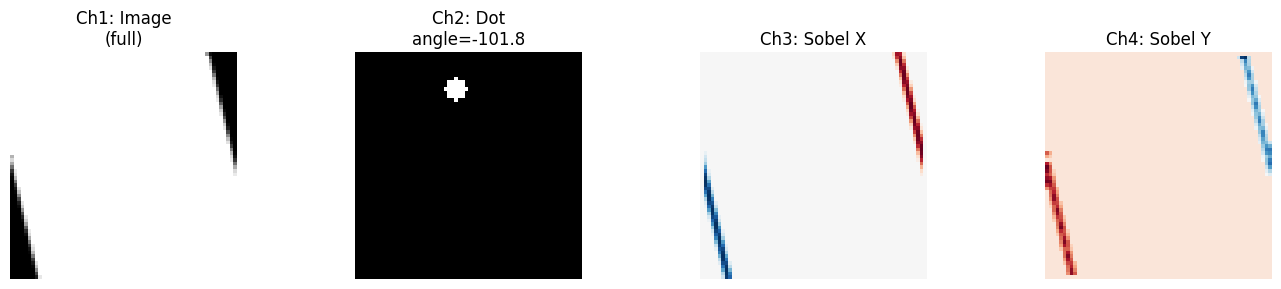

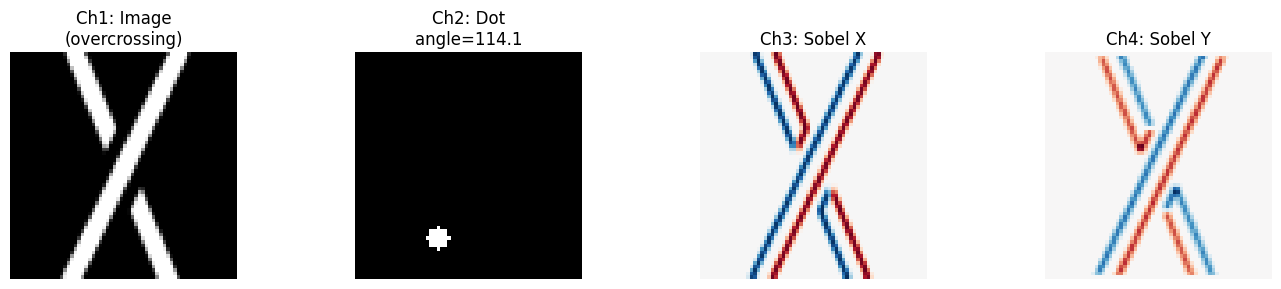

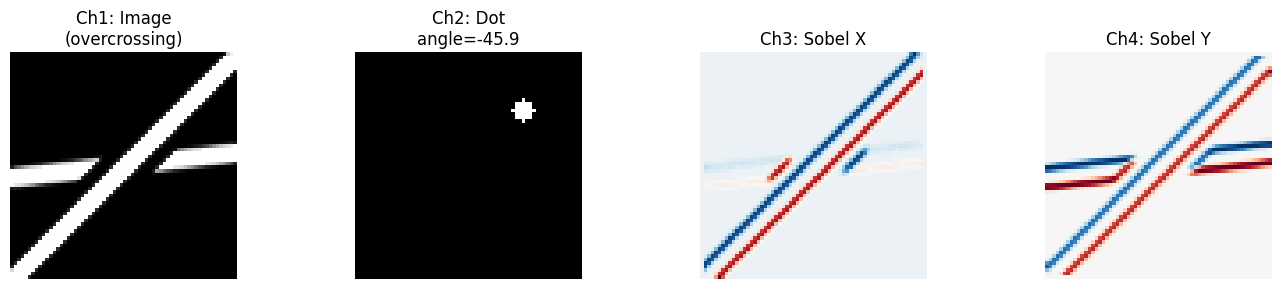

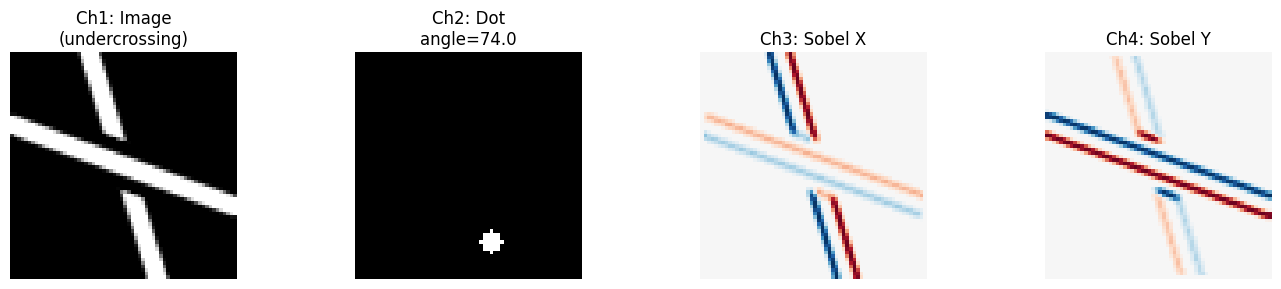

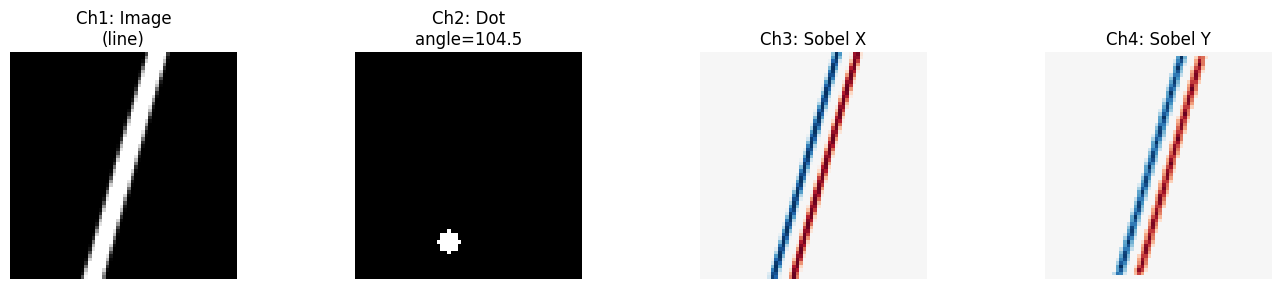

In [12]:
#-------------------------------
# Visualize 5 random crossings with all 4 channels
#-------------------------------

N = 5
THICKNESS = 2

for i in range(N):
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), 255, dtype=np.uint8)

    main_angle = random.uniform(-math.pi, math.pi)
    other_angle = random.uniform(-math.pi, math.pi)
    while abs(math.atan2(math.sin(main_angle - other_angle),
                         math.cos(main_angle - other_angle))) < math.pi / 8:
        other_angle = random.uniform(-math.pi, math.pi)

    cross_choice = random.random()
    if cross_choice < 0.15:
        crossing_type = "empty"
    elif cross_choice < 0.30:
        crossing_type = "full"
        draw_straight_line(img, main_angle, 30)
    elif cross_choice < 0.53:
        crossing_type = "line"
        draw_straight_line(img, main_angle, THICKNESS)
    elif cross_choice < 0.76:
        crossing_type = "overcrossing"
        draw_over_crossing(img, main_angle, other_angle, THICKNESS)
    else:
        crossing_type = "undercrossing"
        draw_under_crossing(img, main_angle, other_angle, THICKNESS)

    inv_img = cv2.bitwise_not(img)
    gray_img = cv2.cvtColor(inv_img, cv2.COLOR_BGR2GRAY)
    gray_float = gray_img / 255.0
    

    dot_channel = make_dot_channel(main_angle)
    sobel_x, sobel_y = compute_sobel_channels(gray_float)
    
    fig, axes = plt.subplots(1, 4, figsize=(14, 3))

    axes[0].imshow(gray_float, cmap='gray')
    axes[0].set_title(f"Ch1: Image\n({crossing_type})")
    axes[1].imshow(dot_channel, cmap='gray')
    axes[1].set_title(f"Ch2: Dot\nangle={math.degrees(main_angle):.1f}")
    axes[2].imshow(sobel_x, cmap='RdBu')
    axes[2].set_title("Ch3: Sobel X")
    axes[3].imshow(sobel_y, cmap='RdBu')
    axes[3].set_title("Ch4: Sobel Y")
    
    
    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


In [5]:
#-------------------------------------
# Image creation loop (8000 images, continuous angles, 5-class crossing)
#--------------------------------------

OUTPUT_DIR = "local_Knot_training_data"
NUM_IMAGES = 16000
TRAIN_RATIO = 0.8
RANDOM_SEED = 42

# Paths
path = os.getcwd()
DATA_DIR = os.path.join(path, os.pardir, 'data', OUTPUT_DIR)
os.makedirs(DATA_DIR, exist_ok=True)

random.seed(RANDOM_SEED)
dataset_labels = []

for i in range(NUM_IMAGES):
    img = np.full((WINDOW_SIZE[1], WINDOW_SIZE[0], 3), -1, dtype=np.uint8)

    thickness = 2

    # Sample random continuous angles (full [-Ï€, Ï€] range)
    main_angle = random.uniform(-math.pi, math.pi)
    other_angle = random.uniform(-math.pi, math.pi)
    # Ensure minimum angular separation between crossing strands (avoid near-parallel)
    while abs(math.atan2(math.sin(main_angle - other_angle),
                         math.cos(main_angle - other_angle))) < math.pi / 8:
        other_angle = random.uniform(-math.pi, math.pi)

    # Crossing type selection (5 classes)
    cross_choice = random.random()
    if cross_choice < 0.125:
        crossing_type, crossing_idx = "empty", 3        # near-blank canvas
    elif cross_choice < 0.25:
        crossing_type, crossing_idx = "full", 4         # oversaturated smear
        draw_straight_line(img, main_angle, 20)
    elif cross_choice < 0.5:
        crossing_type, crossing_idx = "line", 2
        draw_straight_line(img, main_angle, thickness)
    elif cross_choice < 0.75:
        crossing_type, crossing_idx = "overcrossing", 0
        draw_over_crossing(img, main_angle, other_angle, thickness)
    else:
        crossing_type, crossing_idx = "undercrossing", 1
        draw_under_crossing(img, main_angle, other_angle, thickness)

    # Process: invert colors, convert to grayscale, save as jpg
    img = cv2.bitwise_not(img)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    img_filename = f"knot_{i:05d}.jpg"
    img_path = os.path.join(DATA_DIR, img_filename)
    cv2.imwrite(img_path, img)

    dataset_labels.append({
        "filename": img_filename,
        "label_index": i,
        "angle_rad": float(main_angle),   # actual angle used (not rounded to cardinal)
        "crossing": crossing_type,
        "crossing_idx": crossing_idx,
    })

# Split into train/val with fixed seed for reproducibility
n_train = int(NUM_IMAGES * TRAIN_RATIO)
train_labels = dataset_labels[:n_train]
val_labels   = dataset_labels[n_train:]

with open(os.path.join(DATA_DIR, "labels_train.json"), "w") as f:
    json.dump(train_labels, f, indent=4)

with open(os.path.join(DATA_DIR, "labels_val.json"), "w") as f:
    json.dump(val_labels, f, indent=4)

# Also write combined labels for convenience
with open(os.path.join(DATA_DIR, "labels.json"), "w") as f:
    json.dump(dataset_labels, f, indent=4)

print(f"Generated {NUM_IMAGES} images  ({n_train} train / {len(val_labels)} val)  in '{OUTPUT_DIR}'")


Generated 16000 images  (12800 train / 3200 val)  in 'local_Knot_training_data'
